In [6]:
import numpy as np
import matplotlib.pyplot as plt

## This code numerically implements single particle quantum hopping problem with a floquet rate

The Hamiltonian of the problem reads:
$$
H = -J\sum_{x} f(kx - wt) \ket{x+1}\bra{x} + h.c
$$
There are a few physically meaningful parameters in our model:
+ $J$ can be thought of as the hopping velocity (or force maybe), which characterize how strongly your particle can hop onto the next. Using some tight-binding analogy, we deduced that basically $aJ$, where $a$ is the lattice spacing that we for now take to be $1$, is the maximum velocity of the particle.
+ The term $f(kx - wt)$ can be thought of as a potential. The $2$ relevant parameters are $2\pi/k$ describe the wavelength of this potential (spatial periodicity), and $w$ basically tell you how fast this potential is changing over time. A natural parameter deduced from this is the potential of this $v = w/k$, which tells you how fast this potential is moving.  

In [9]:
# ============================================================
# Schrodinger's equation functions
# ============================================================

def allowed_k(L, m):
    """
    Enforce periodic boundary condition compatibility:
        k = 2*pi*m / L
    """
    return 2 * np.pi * m / L


def hopping_profile(x, t, J, k, omega):
    """
    Bond amplitude on bond x -> x+1:
        a_x(t) = -J cos(k x - omega t)

    The minus sign is included here so the RHS reads naturally.
    """
    return -J * np.cos(k * x - omega * t)


def schrodinger_rhs(t, psi, L, J, k, omega):
    """
    Right-hand side of
        d psi / dt = -i H(t) psi

    using the site-basis nearest-neighbor equation directly.

    For each site x:
        i d/dt psi_x =
            a_{x-1}(t) psi_{x-1}
          + a_x(t)     psi_{x+1}

    where
        a_x(t) = -J cos(kx - omega t)

    with periodic boundary conditions.
    """
    dpsi = np.zeros(L, dtype=np.complex128)

    for x in range(L):
        xm1 = (x - 1) % L
        xp1 = (x + 1) % L

        a_left = hopping_profile(xm1, t, J, k, omega)   # bond (x-1) -> x
        a_right = hopping_profile(x, t, J, k, omega)    # bond x -> (x+1)

        # Since cos(...) is real, Hermitian conjugate is automatically handled
        # by the symmetric coupling to neighbors.
        dpsi[x] = -1j * (a_left * psi[xm1] + a_right * psi[xp1])

    return dpsi

In [10]:
# ============================================================
# Initial states
# ============================================================

def delta_initial_state(L, x0):
    """
    Fully localized state at site x0.
    """
    psi0 = np.zeros(L, dtype=np.complex128)
    psi0[x0 % L] = 1.0
    return psi0


def gaussian_initial_state(L, x0, sigma=3.0, q0=0.0):
    """
    Gaussian wavepacket on a ring:
        psi_x ~ exp[-(dx)^2 / (2 sigma^2)] * exp(i q0 x)

    where dx is the shortest distance on the ring.
    """
    x = np.arange(L, dtype=float)
    dx = (x - x0 + L / 2.0) % L - L / 2.0
    psi0 = np.exp(-(dx**2) / (2.0 * sigma**2)) * np.exp(1j * q0 * x)
    psi0 = psi0.astype(np.complex128)
    psi0 /= np.linalg.norm(psi0)
    return psi0

In [11]:
# ============================================================
# Time evolution
# ============================================================
def evolve_state_predictor_corrector(L, J, omega, m, psi0, t_max, n_times=400,
                                     n_substeps=20, renormalize_each_step=True):
    """
    Evolve the state using a predictor-corrector method
    (Heun / explicit trapezoid) built directly from the stencil RHS.

    Parameters
    ----------
    L : int
        Number of sites.
    J : float
        Hopping strength.
    omega : float
        Drive frequency.
    m : int
        Integer setting k = 2*pi*m/L.
    psi0 : ndarray, shape (L,)
        Initial state.
    t_max : float
        Final time.
    n_times : int
        Number of output times.
    n_substeps : int
        Number of predictor-corrector substeps between consecutive output times.
        Increase this if agreement with scipy/RK4 is not good enough.
    renormalize_each_step : bool
        If True, normalize after every corrected step to suppress
        long-time numerical drift.

    Returns
    -------
    t_eval : ndarray, shape (n_times,)
    psi_t : ndarray, shape (n_times, L)
    k : float
    """
    k = allowed_k(L, m)

    psi0 = np.asarray(psi0, dtype=np.complex128)
    if psi0.shape != (L,):
        raise ValueError(f"psi0 must have shape ({L},)")

    t_eval = np.linspace(0.0, t_max, n_times)
    psi_t = np.zeros((n_times, L), dtype=np.complex128)

    psi = psi0.copy()
    psi /= np.linalg.norm(psi)
    psi_t[0] = psi

    if n_times < 2:
        return t_eval, psi_t, k

    dt_out = t_eval[1] - t_eval[0]
    dt = dt_out / n_substeps

    t = t_eval[0]

    for it in range(1, n_times):
        for _ in range(n_substeps):
            # Predictor: forward Euler
            f_n = schrodinger_rhs(t, psi, L, J, k, omega)
            psi_pred = psi + dt * f_n

            # Corrector: trapezoid / Heun step
            f_pred = schrodinger_rhs(t + dt, psi_pred, L, J, k, omega)
            psi = psi + 0.5 * dt * (f_n + f_pred)

            if renormalize_each_step:
                psi /= np.linalg.norm(psi)

            t += dt

        psi_t[it] = psi

    # final cleanup
    norms = np.linalg.norm(psi_t, axis=1, keepdims=True)
    psi_t = psi_t / norms

    return t_eval, psi_t, k


In [12]:
# ============================================================
# Observables
# ============================================================

def probabilities(psi_t):
    """
    Site probabilities P_x(t) = |psi_x(t)|^2
    """
    return np.abs(psi_t)**2


def norm_vs_time(psi_t):
    """
    Norm at each time.
    """
    return np.sum(np.abs(psi_t)**2, axis=1)


def x_expectation(psi_t):
    """
    Naive <x>. Useful mainly before wrap-around becomes important.
    """
    L = psi_t.shape[1]
    x = np.arange(L, dtype=float)
    prob = probabilities(psi_t)
    return prob @ x


def x2_expectation(psi_t):
    """
    Naive <x^2>.
    """
    L = psi_t.shape[1]
    x = np.arange(L, dtype=float)
    prob = probabilities(psi_t)
    return prob @ (x**2)


def width_vs_time(psi_t):
    """
    Naive width sqrt(<x^2> - <x>^2).
    """
    x1 = x_expectation(psi_t)
    x2 = x2_expectation(psi_t)
    var = np.maximum(x2 - x1**2, 0.0)
    return np.sqrt(var)


def total_current(psi_t, t_eval, L, J, omega, m):
    """
    Total bond current:
        I(t) = sum_x j_x(t)

    with
        j_x(t) = 2 Im[ a_x(t) psi_x^*(t) psi_{x+1}(t) ]
    where
        a_x(t) = -J cos(kx - omega t)
    """
    k = allowed_k(L, m)
    currents = np.zeros(len(t_eval), dtype=float)

    for it, t in enumerate(t_eval):
        psi = psi_t[it]
        total_j = 0.0
        for x in range(L):
            xp1 = (x + 1) % L
            a_x = hopping_profile(x, t, J, k, omega)
            total_j += 2.0 * np.imag(a_x * np.conjugate(psi[x]) * psi[xp1])
        currents[it] = total_j

    return currents

In [32]:
# ============================================================
# Plotting
# ============================================================

def plot_probability_snapshot(psi_t, time_index, title=None):
    """
    Plot P_x at one selected time.
    Since x is discrete, we plot probability site by site.
    """
    prob = np.abs(psi_t[time_index])**2
    x = np.arange(len(prob))

    plt.figure(figsize=(8, 4))
    plt.plot(x, prob, marker='o', linestyle='-', ms=3)
    plt.xlabel("site x")
    plt.ylabel(r"$|\psi_x|^2$")
    if title is None:
        title = f"Probability snapshot at index {time_index}"
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_density_map(t_eval, psi_t, vmax=None):
    """
    Heatmap of P_x(t) = |psi_x(t)|^2.
    """
    prob = probabilities(psi_t)
    L = psi_t.shape[1]

    plt.figure(figsize=(10, 5))
    plt.imshow(
        prob.T,
        aspect='auto',
        origin='lower',
        extent=[t_eval[0], t_eval[-1], 0, L - 1],
        vmax=vmax,
        cmap='jet'
    )
    plt.colorbar(label=r"$|\psi_x(t)|^2$")
    plt.xlabel("time t")
    plt.ylabel("site x")
    plt.title("Density map on the ring")
    plt.tight_layout()
    plt.show()


def plot_basic_observables(t_eval, psi_t, L, J, omega, m):
    """
    Plot norm, naive <x>, width, and total current.
    """
    norms = norm_vs_time(psi_t)
    x_mean = x_expectation(psi_t)
    widths = width_vs_time(psi_t)
    currents = total_current(psi_t, t_eval, L, J, omega, m)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].plot(t_eval, norms)
    axes[0, 0].set_title("Norm")
    axes[0, 0].set_xlabel("t")
    axes[0, 0].set_ylabel(r"$\langle \psi | \psi \rangle$")

    axes[0, 1].plot(t_eval, x_mean)
    axes[0, 1].set_title(r"Naive $\langle x \rangle$")
    axes[0, 1].set_xlabel("t")
    axes[0, 1].set_ylabel(r"$\langle x \rangle$")

    axes[1, 0].plot(t_eval, widths)
    axes[1, 0].set_title("Naive width")
    axes[1, 0].set_xlabel("t")
    axes[1, 0].set_ylabel("width")

    axes[1, 1].plot(t_eval, currents)
    axes[1, 1].set_title("Total current")
    axes[1, 1].set_xlabel("t")
    axes[1, 1].set_ylabel("I(t)")

    plt.tight_layout()
    plt.show()

L = 200
J = 1.0
omega = 1.5
m = 10
k = 2*pi*m/L = 0.314159
Initial state: Delta state at site 100


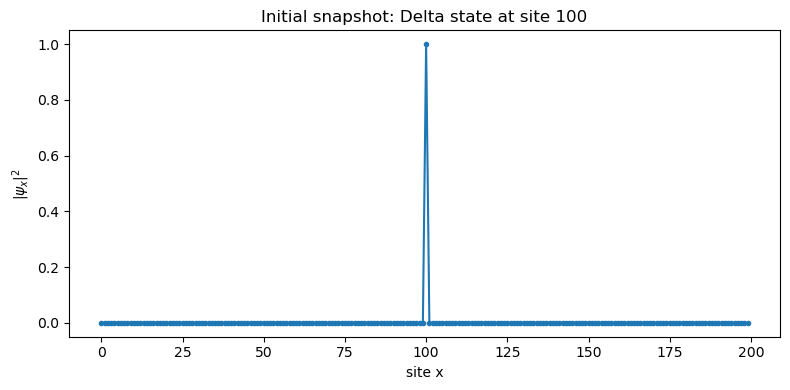

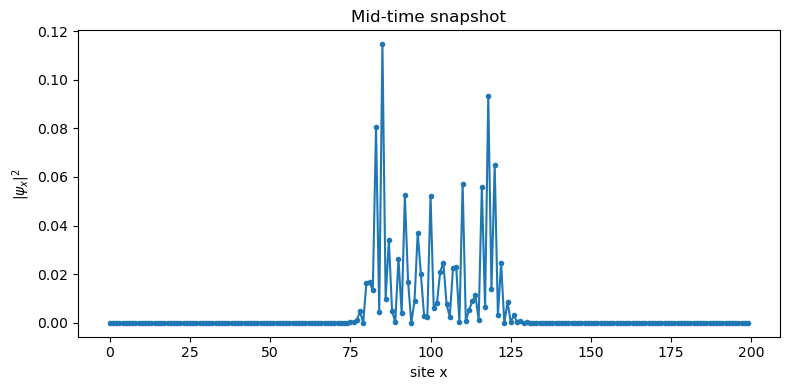

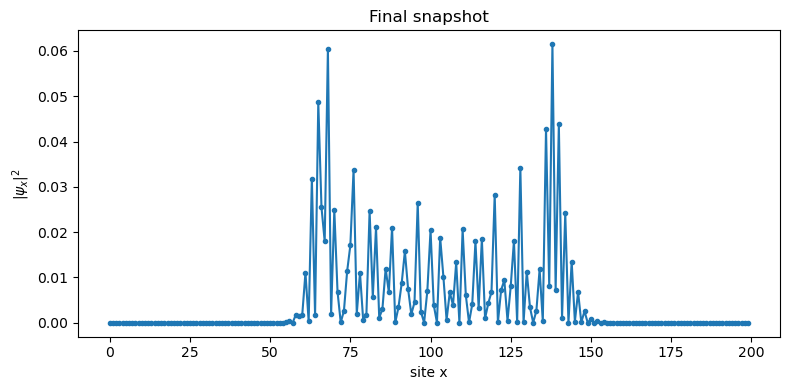

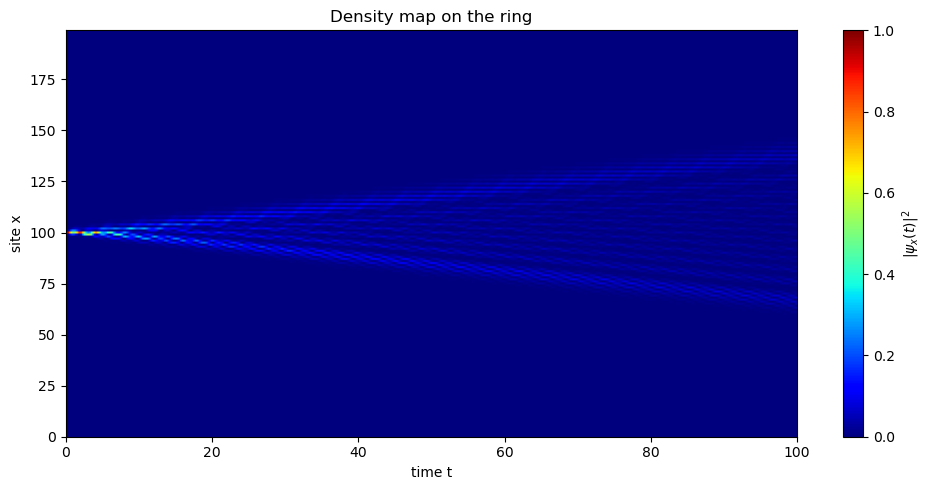

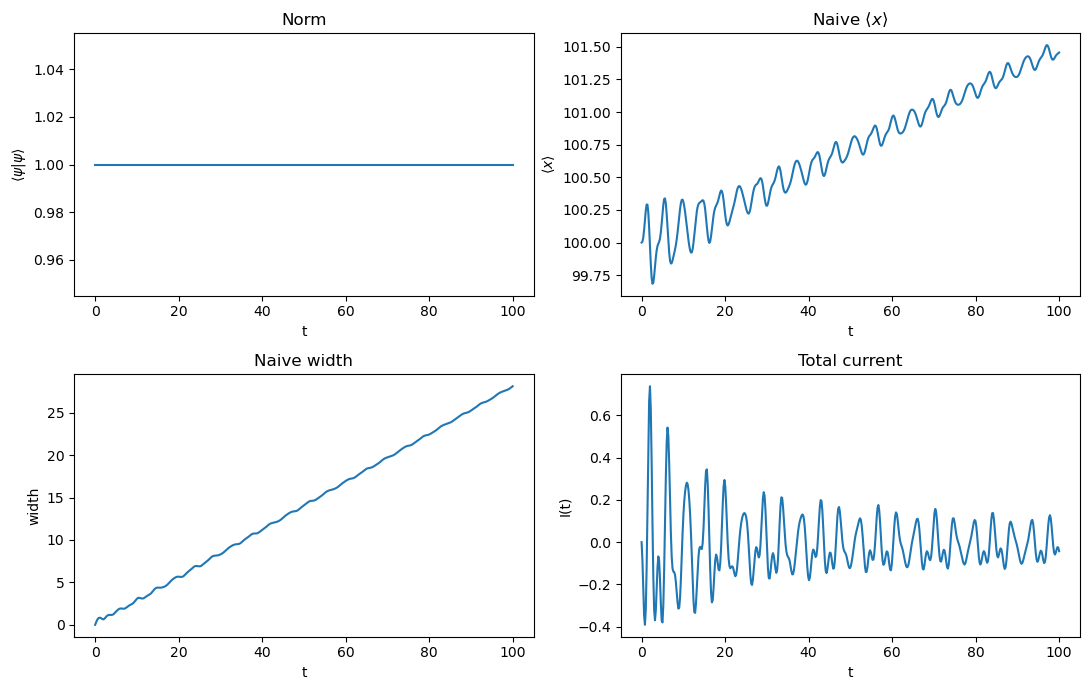

In [104]:
L = 200          # system size
J = 1.0          # hopping scale
omega = 1.5     # drive frequency
m = 10          # sets k = 2*pi*m/L

t_max = 100
n_times = 500

k = allowed_k(L, m)
# T = 2.0 * np.pi / omega

print(f"L = {L}")
print(f"J = {J}")
print(f"omega = {omega}")
print(f"m = {m}")
print(f"k = 2*pi*m/L = {k:.6f}")
# print(f"Drive period T = {T:.6f}")

# --------------------------------------------------------
# Choose initial state
# --------------------------------------------------------

# Option 1: delta-function localized at one site
x0_delta = round(L/2)
psi0_delta = delta_initial_state(L, x0_delta)

# Option 2: Gaussian packet
x0_gauss = L // 2
sigma = 1
q0 = 0.0
psi0_gauss = gaussian_initial_state(L, x0_gauss, sigma=sigma, q0=q0)

# --------------------------------------------------------
# Evolve one of them
# --------------------------------------------------------
use_gaussian = False


if use_gaussian:
    psi0 = psi0_gauss
    init_name = f"Gaussian packet (x0={x0_gauss}, sigma={sigma}, q0={q0})"
else:
    psi0 = psi0_delta
    init_name = f"Delta state at site {x0_delta}"

print(f"Initial state: {init_name}")

t_eval, psi_t, k = evolve_state_predictor_corrector(
    L=L,
    J=J,
    omega=omega,
    m=m,
    psi0=psi0,
    t_max=t_max,
    n_times=n_times
)

# --------------------------------------------------------
# Plots
# --------------------------------------------------------
plot_probability_snapshot(psi_t, 0, title=f"Initial snapshot: {init_name}")
plot_probability_snapshot(psi_t, len(t_eval)//2, title="Mid-time snapshot")
plot_probability_snapshot(psi_t, -1, title="Final snapshot")

plot_density_map(t_eval, psi_t)
plot_basic_observables(t_eval, psi_t, L, J, omega, m)

## Some thing we learned 
+ First consier the regime in which $v_F << v_{\text{max}}$, where $v_F$ is the velocity of the floquet part. First, when $v_F = 0$ the physics follows: the peridic potential creates bumps in which the potential will spend most of their time in. But then, the particle will slowly tunnel through the barriers created by this periodic potential, symmetrically between left and right. This can be observed in the heat map overtime of the probability function. Then, imagine you start the turn the $w$ on, which makes the potential slowly moves to the right. This makes the probability of tunneling to the right a little bit smaller, therefore creating a drift to the left.
+ Another thing that we think are interesting is the fact that at $k = \pi$, or when the potential at $x,x+1$ is exactly opposite sign and equal magnitude. When this happens, you are basically symmetric between left and right, which result in no motion.
+ Now, there is something that we have seen that is pretty interesting: it seems like the value of $k$ will determine the directions of the particle, and the value of $w$ will determine the value of such velocity. 

## Things to do
+ Even though we now that the $v_{\text{max}}$ of the particle is determined by $aJ$, we do not know what is the actual velocity of the particle is. For this, it will be good to have a calculations of this velocity for different parameters. Our goal will be to make a heat map of $v/v_F$ as a function of $ak$ and $J/w$ (dimensionless parameter) 


### 4/18/26
+ Below are cells that help us determine the velocity of the particle as a function of both $w/J$ and $ak$. We will first consider a line cut of this $2$ dimensional functions, for example, fix $k$ and change $w$.

In [105]:
# ============================================================
# Helpers for velocity extraction
# ============================================================

def linear_fit_slope(t, y):
    """
    Return slope from a linear fit y ~ slope * t + intercept.
    """
    p = np.polyfit(t, y, 1)
    return p[0]

def endpoint_slope(t, y):
    """
    Return (y[-1] - y[0]) / (t[-1] - t[0]).
    """
    return (y[-1] - y[0]) / (t[-1] - t[0])

def unwrap_periodic_coordinate(x_mean, L, jump_threshold=None):
    """
    Unwrap a position-like trajectory defined on a ring.

    Parameters
    ----------
    x_mean : 1D array
        Raw <x>(t), typically in [0, L).
    L : int
        Ring size.
    jump_threshold : float or None
        If None, use L/2. Jumps larger than this are interpreted as wrapping.

    Returns
    -------
    x_unwrapped : 1D array
    """
    x_mean = np.asarray(x_mean, dtype=float)
    if jump_threshold is None:
        jump_threshold = L / 2.0

    x_unwrapped = np.zeros_like(x_mean)
    x_unwrapped[0] = x_mean[0]

    offset = 0.0
    for i in range(1, len(x_mean)):
        dx = x_mean[i] - x_mean[i - 1]

        if dx > jump_threshold:
            offset -= L
        elif dx < -jump_threshold:
            offset += L

        x_unwrapped[i] = x_mean[i] + offset

    return x_unwrapped

def estimate_velocities_from_observable(t_eval, y, unwrap_L=None):
    """
    Compute endpoint and fit velocities from observable y(t).

    If unwrap_L is not None, first unwrap y as a periodic coordinate on a ring.
    """
    y_proc = y.copy()
    if unwrap_L is not None:
        y_proc = unwrap_periodic_coordinate(y_proc, unwrap_L)

    v_end = endpoint_slope(t_eval, y_proc)
    v_fit = linear_fit_slope(t_eval, y_proc)

    # Right now we do not implement the unwrap because there is not good measure yet
    return {
        # "y_processed": y_proc,
        "v_endpoint": v_end,
        "v_fit": v_fit,
    }



In [106]:
# ============================================================
# Single-run analysis
# ============================================================

def analyze_single_run_velocity(L, J, omega, m, psi0, t_max, n_times=500,
                                n_substeps=20):
    """
    Run one evolution and extract velocity diagnostics.

    Returns dict with:
      - t_eval
      - psi_t
      - x_mean_raw
      - x_mean_unwrapped
      - width
      - velocities from <x> and width, endpoint + fit
    """
    # if solver == "scipy":
    #     t_eval, psi_t, k = evolve_state_scipy_integrate(
    #         L=L, J=J, omega=omega, m=m, psi0=psi0,
    #         t_max=t_max, n_times=n_times
    #     )
    # elif solver == "rk4":
    #     t_eval, psi_t, k = evolve_state_direct_stencil(
    #         L=L, J=J, omega=omega, m=m, psi0=psi0,
    #         t_max=t_max, n_times=n_times, n_substeps=n_substeps
    #     )
    # elif solver == "pc":
    t_eval, psi_t, k = evolve_state_predictor_corrector(
        L=L, J=J, omega=omega, m=m, psi0=psi0,
        t_max=t_max, n_times=n_times, n_substeps=n_substeps
    )
    # else:
    #     raise ValueError("solver must be 'scipy', 'rk4', or 'pc'")

    x_mean_raw = x_expectation(psi_t)
    x_stats = estimate_velocities_from_observable(t_eval, x_mean_raw, unwrap_L= None)

    width = width_vs_time(psi_t)
    width_stats = estimate_velocities_from_observable(t_eval, width, unwrap_L=None)

    return {
        "t_eval": t_eval,
        "psi_t": psi_t,
        "k": k,
        "x_mean_raw": x_mean_raw,
        # "x_mean_unwrapped": x_stats["y_processed"],
        "width": width,
        "vx_endpoint": x_stats["v_endpoint"],
        "vx_fit": x_stats["v_fit"],
        "vwidth_endpoint": width_stats["v_endpoint"],
        "vwidth_fit": width_stats["v_fit"],
    }

In [107]:
# ============================================================
# Sweep omega/J at fixed m (and thus fixed k for fixed L)
# ============================================================

def sweep_omega_velocity(L, J, m, omega_over_J_values, psi0, t_max,
                         n_times=500, n_substeps=20):
    """
    Sweep omega/J and extract velocities.

    Returns a dict of arrays.
    """
    k = allowed_k(L, m)
    v_max = J   # with a=1

    results = {
        "omega_over_J": [],
        "omega": [],
        "k": [],
        "vx_endpoint": [],
        "vx_fit": [],
        "vwidth_endpoint": [],
        "vwidth_fit": [],
        "vx_endpoint_over_vmax": [],
        "vx_fit_over_vmax": [],
        "vwidth_endpoint_over_vmax": [],
        "vwidth_fit_over_vmax": [],
    }

    for omega_over_J in omega_over_J_values:
        omega = omega_over_J * J

        out = analyze_single_run_velocity(
            L=L, J=J, omega=omega, m=m, psi0=psi0,
            t_max=t_max, n_times=n_times,
            n_substeps=n_substeps
        )

        results["omega_over_J"].append(omega_over_J)
        results["omega"].append(omega)
        results["k"].append(k)

        results["vx_endpoint"].append(out["vx_endpoint"])
        results["vx_fit"].append(out["vx_fit"])
        results["vwidth_endpoint"].append(out["vwidth_endpoint"])
        results["vwidth_fit"].append(out["vwidth_fit"])

        results["vx_endpoint_over_vmax"].append(out["vx_endpoint"] / v_max)
        results["vx_fit_over_vmax"].append(out["vx_fit"] / v_max)
        results["vwidth_endpoint_over_vmax"].append(out["vwidth_endpoint"] / v_max)
        results["vwidth_fit_over_vmax"].append(out["vwidth_fit"] / v_max)

    for key in results:
        results[key] = np.array(results[key])

    return results

# ============================================================
# Sweep several k values (implemented via m values)
# ============================================================

def sweep_multiple_k_values(L, J, m_values, omega_over_J_values, psi0, t_max,
                            n_times=500, n_substeps=20):
    """
    Run sweep_omega_velocity for several m values.

    Returns dict keyed by m.
    """
    all_results = {}
    for m in m_values:
        all_results[m] = sweep_omega_velocity(
            L=L, J=J, m=m,
            omega_over_J_values=omega_over_J_values,
            psi0=psi0, t_max=t_max,
            n_times=n_times, n_substeps=n_substeps
        )
    return all_results


In [108]:
# ============================================================
# Plotting
# ============================================================

def plot_velocity_vs_omega(results, J, title_prefix=""):
    """
    Plot v/v_max as function of omega/J.
    """
    omg = results["omega_over_J"]

    plt.figure(figsize=(8, 5))
    plt.plot(omg, results["vx_endpoint_over_vmax"], 'o-', label=r'$\langle x\rangle$: endpoint')
    plt.plot(omg, results["vx_fit_over_vmax"], 's-', label=r'$\langle x\rangle$: fit')
    plt.plot(omg, results["vwidth_endpoint_over_vmax"], 'o--', label='width: endpoint')
    plt.plot(omg, results["vwidth_fit_over_vmax"], 's--', label='width: fit')
    plt.axhline(0.0, color='k', linewidth=0.8)
    plt.xlabel(r'$\omega/J$')
    plt.ylabel(r'$v / v_{\max}$')
    plt.title(f'{title_prefix} velocity ratios vs ' + r'$\omega/J$')
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_example_trajectory(L, J, omega, m, psi0, t_max, n_times=500,
                            n_substeps=20):
    """
    Plot raw and unwrapped <x>(t), plus width(t), for one parameter choice.
    """
    out = analyze_single_run_velocity(
        L=L, J=J, omega=omega, m=m, psi0=psi0,
        t_max=t_max, n_times=n_times,
         n_substeps=n_substeps
    )

    t = out["t_eval"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(t, out["x_mean_raw"], label='raw')
    axes[0].plot(t, out["x_mean_unwrapped"], label='unwrapped')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel(r'$\langle x \rangle$')
    axes[0].set_title(r'$\langle x \rangle(t)$')
    axes[0].legend()

    axes[1].plot(t, out["width"])
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('width')
    axes[1].set_title('width(t)')

    plt.tight_layout()
    plt.show()

Initial state: Delta state at site 100


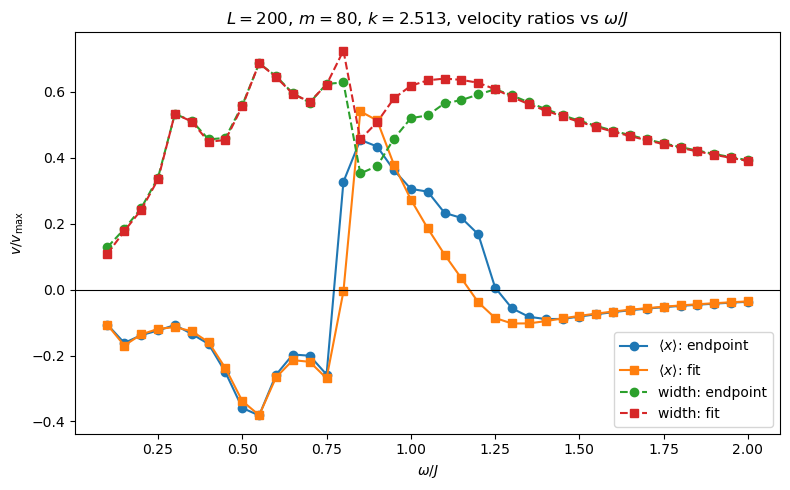

In [112]:
# ============================================================
# Example run for your requested parameters
# ============================================================

if __name__ == "__main__":
    # Requested parameters
    L = 200
    J = 1.0
    m = 80
    t_max = 100.0
    n_times = 500

    # Initial state: center in middle, moderate width
    x0 = L // 2
    sigma = 4.0
    q0 = 0.0
    # Option 1: delta-function localized at one site
    x0_delta = round(L/2)
    psi0_delta = delta_initial_state(L, x0_delta)

    # Option 2: Gaussian packet
    x0_gauss = L // 2
    sigma = 1
    q0 = 0.0
    psi0_gauss = gaussian_initial_state(L, x0_gauss, sigma=sigma, q0=q0)

    # --------------------------------------------------------
    # Evolve one of them
    # --------------------------------------------------------
    use_gaussian = False


    if use_gaussian:
        psi0 = psi0_gauss
        init_name = f"Gaussian packet (x0={x0_gauss}, sigma={sigma}, q0={q0})"
    else:
        psi0 = psi0_delta
        init_name = f"Delta state at site {x0_delta}"

    print(f"Initial state: {init_name}")

    # Sweep omega/J = 0.1, 0.2, ..., 5.0
    omega_over_J_values = np.arange(0.1, 2.0 + 1e-12, 0.05)

    # Run sweep
    results = sweep_omega_velocity(
        L=L,
        J=J,
        m=m,
        omega_over_J_values=omega_over_J_values,
        psi0=psi0,
        t_max=t_max,
        n_times=n_times,
        # solver="scipy"   # or "rk4", "pc"
    )

    # Plot requested v/v_max vs omega/J
    plot_velocity_vs_omega(results, J, title_prefix=fr"$L={L},\, m={m},\, k={allowed_k(L,m):.3f}$,")

    # # Optional: inspect one trajectory
    # plot_example_trajectory(
    #     L=L, J=J, omega=1.0, m=m, psi0=psi0,
    #     t_max=t_max, n_times=n_times,
    # )

In [ ]:
def sweep_k_omega_velocity_grid(L, J, m_values, omega_over_J_values, psi0_builder,
                                t_max, n_times=500, solver="scipy", n_substeps=20):
    """
    2D sweep over allowed k values (via m) and omega/J.

    Parameters
    ----------
    L, J : system parameters
    m_values : 1D array-like of ints
        Allowed k values are k = 2*pi*m/L.
    omega_over_J_values : 1D array-like
    psi0_builder : callable
        Function psi0_builder(L, m, omega_over_J) -> psi0
        Lets you customize initial state if desired.
    t_max, n_times : evolution settings

    Returns
    -------
    results : dict
        Contains axes and 2D arrays with shape (len(m_values), len(omega_over_J_values))
    """
    m_values = np.array(m_values, dtype=int)
    omega_over_J_values = np.array(omega_over_J_values, dtype=float)

    n_k = len(m_values)
    n_w = len(omega_over_J_values)

    k_values = 2.0 * np.pi * m_values / L
    v_max = 2.0 * J  # a=1

    vx_endpoint = np.zeros((n_k, n_w))
    vx_fit = np.zeros((n_k, n_w))
    vwidth_endpoint = np.zeros((n_k, n_w))
    vwidth_fit = np.zeros((n_k, n_w))

    for i, m in enumerate(m_values):
        for j, omega_over_J in enumerate(omega_over_J_values):
            omega = omega_over_J * J
            psi0 = psi0_builder(L, m, omega_over_J)

            out = analyze_single_run_velocity(
                L=L, J=J, omega=omega, m=m, psi0=psi0,
                t_max=t_max, n_times=n_times,
                solver=solver, n_substeps=n_substeps
            )

            vx_endpoint[i, j] = out["vx_endpoint"]
            vx_fit[i, j] = out["vx_fit"]
            vwidth_endpoint[i, j] = out["vwidth_endpoint"]
            vwidth_fit[i, j] = out["vwidth_fit"]

    results = {
        "L": L,
        "J": J,
        "m_values": m_values,
        "k_values": k_values,
        "omega_over_J_values": omega_over_J_values,
        "vx_endpoint": vx_endpoint,
        "vx_fit": vx_fit,
        "vwidth_endpoint": vwidth_endpoint,
        "vwidth_fit": vwidth_fit,
        "vx_endpoint_over_vmax": vx_endpoint / v_max,
        "vx_fit_over_vmax": vx_fit / v_max,
        "vwidth_endpoint_over_vmax": vwidth_endpoint / v_max,
        "vwidth_fit_over_vmax": vwidth_fit / v_max,
    }
    return results


def plot_velocity_heatmap(results, observable="vx_fit_over_vmax", title=None):
    """
    Heatmap over (omega/J, k).
    """
    Z = results[observable]
    x = results["omega_over_J_values"]
    y = results["k_values"]

    plt.figure(figsize=(8, 5))
    plt.imshow(
        Z,
        aspect='auto',
        origin='lower',
        extent=[x[0], x[-1], y[0], y[-1]]
    )
    plt.colorbar(label=observable)
    plt.xlabel(r'$\omega/J$')
    plt.ylabel(r'$k$')
    if title is None:
        title = observable
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_velocity_linecuts(results, m_indices=None, observable="vx_fit_over_vmax"):
    """
    Plot v/vmax vs omega/J for selected k indices.
    """
    x = results["omega_over_J_values"]
    k_values = results["k_values"]
    Z = results[observable]

    if m_indices is None:
        m_indices = range(len(k_values))

    plt.figure(figsize=(8, 5))
    for idx in m_indices:
        plt.plot(x, Z[idx], label=fr'$k={k_values[idx]:.3f}$')
    plt.xlabel(r'$\omega/J$')
    plt.ylabel(observable)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
if __name__ == "__main__":
    L = 200
    J = 1.0
    t_max = 100.0
    n_times = 600

    m_values = np.arange(1, 31)                 # sweeps k = 2*pi*m/L
    omega_over_J_values = np.arange(0.1, 5.1, 0.1)

    def psi0_builder(L, m, omega_over_J):
        x0 = L // 2
        sigma = 4.0
        q0 = 0.0
        return gaussian_initial_state(L, x0=x0, sigma=sigma, q0=q0)

    results = sweep_k_omega_velocity_grid(
        L=L,
        J=J,
        m_values=m_values,
        omega_over_J_values=omega_over_J_values,
        psi0_builder=psi0_builder,
        t_max=t_max,
        n_times=n_times,
        solver="scipy"
    )

    plot_velocity_heatmap(
        results,
        observable="vx_fit_over_vmax",
        title=r"Drift velocity from fit of $\langle x \rangle$"
    )

    plot_velocity_heatmap(
        results,
        observable="vwidth_fit_over_vmax",
        title=r"Spreading velocity from fit of width"
    )

In [15]:

# ============================================================
# Benchmark: Loop vs Matrix Multiplication
# ============================================================
import time
from scipy.sparse import diags, csr_matrix

def schrodinger_rhs_matrix_dense(t, psi, L, J, k, omega):
    """
    RHS using dense matrix multiplication:
        dpsi = -i * H(t) @ psi
    """
    H = np.zeros((L, L), dtype=np.complex128)
    
    for x in range(L):
        xm1 = (x - 1) % L
        xp1 = (x + 1) % L
        
        a_left = hopping_profile(xm1, t, J, k, omega)
        a_right = hopping_profile(x, t, J, k, omega)
        
        H[x, xm1] = a_left
        H[x, xp1] = a_right
    
    return -1j * (H @ psi)


def schrodinger_rhs_matrix_sparse(t, psi, L, J, k, omega):
    """
    RHS using sparse matrix multiplication.
    """
    diag_left = np.array([hopping_profile(x, t, J, k, omega) for x in range(L)])
    diag_right = np.roll(diag_left, 1)
    
    # Build sparse matrix: each row x has non-zero entries at (x, x-1) and (x, x+1)
    offsets = [-1, 1]
    diagonals = [diag_left, diag_right]
    H = diags(diagonals, offsets=offsets, shape=(L, L), format='csr', dtype=np.complex128)
    
    return -1j * (H @ psi)


def benchmark_implementations(L, J, omega, m, n_rhs_calls=1000):
    """
    Benchmark the three approaches.
    """
    k = allowed_k(L, m)
    psi = gaussian_initial_state(L, L//2, sigma=5)
    t = 0.0
    
    # Warmup
    for _ in range(10):
        schrodinger_rhs(t, psi, L, J, k, omega)
    
    # Loop-based (your current approach)
    start = time.perf_counter()
    for _ in range(n_rhs_calls):
        _ = schrodinger_rhs(t, psi, L, J, k, omega)
    time_loop = time.perf_counter() - start
    
    # Dense matrix
    start = time.perf_counter()
    for _ in range(n_rhs_calls):
        _ = schrodinger_rhs_matrix_dense(t, psi, L, J, k, omega)
    time_dense = time.perf_counter() - start
    
    # Sparse matrix
    start = time.perf_counter()
    for _ in range(n_rhs_calls):
        _ = schrodinger_rhs_matrix_sparse(t, psi, L, J, k, omega)
    time_sparse = time.perf_counter() - start
    
    return time_loop, time_dense, time_sparse


# Run benchmark
print("=" * 60)
print("RHS Evaluation Benchmark (1000 calls)")
print("=" * 60)

L_values = [50, 100, 200, 500]

for L in L_values:
    time_loop, time_dense, time_sparse = benchmark_implementations(L, J=5.0, omega=2.0, m=L//3, n_rhs_calls=1000)
    
    print(f"\nL = {L}:")
    print(f"  Loop-based:      {time_loop*1000:.3f} ms")
    print(f"  Dense matrix:    {time_dense*1000:.3f} ms  ({time_dense/time_loop:.1f}x)")
    print(f"  Sparse matrix:   {time_sparse*1000:.3f} ms  ({time_sparse/time_loop:.1f}x)")
    print(f"  → Sparse is {time_loop/time_sparse:.1f}x faster than your loop")


RHS Evaluation Benchmark (1000 calls)

L = 50:
  Loop-based:      57.615 ms
  Dense matrix:    33.748 ms  (0.6x)
  Sparse matrix:   56.558 ms  (1.0x)
  → Sparse is 1.0x faster than your loop

L = 100:
  Loop-based:      73.608 ms
  Dense matrix:    159.889 ms  (2.2x)
  Sparse matrix:   129.311 ms  (1.8x)
  → Sparse is 0.6x faster than your loop

L = 200:
  Loop-based:      240.520 ms
  Dense matrix:    260.884 ms  (1.1x)
  Sparse matrix:   143.712 ms  (0.6x)
  → Sparse is 1.7x faster than your loop

L = 500:
  Loop-based:      408.015 ms
  Dense matrix:    948.907 ms  (2.3x)
  Sparse matrix:   229.032 ms  (0.6x)
  → Sparse is 1.8x faster than your loop
